# Artificial Neural Network — Handwritten Digit Recognition
## Student: Marvin Adorian Zanchi Santos | Student Number: C00288302

## Project Overview

This notebook implements an **Artificial Neural Network (ANN)** to recognise handwritten digits (0–9). The model is then deployed in an interactive **Streamlit application** where users can draw digits with the mouse and see real-time predictions.

**Dataset:** MNIST (70,000 grayscale images, 28×28 pixels)  
**Objective:** Classify handwritten digits with high accuracy and deploy as an interactive demo.

### Real-World Applications
- **Postal services:** Automated reading of postcodes and addresses
- **Banking:** Cheque amount recognition
- **Forms processing:** Digitising handwritten forms and surveys
- **Mobile input:** Handwriting recognition on touchscreens

### Key Concepts
- **Neurons & Layers:** Interconnected processing units organised in layers
- **Activation Functions:** ReLU (hidden layers) and Softmax (output layer)
- **Backpropagation:** Learning by adjusting weights to minimise prediction errors
- **Dropout:** Regularisation technique to prevent overfitting
- **Epochs:** Number of complete passes through the training data

---
## Work Log

| Date | Task | Details |
|------|------|---------|
| 17/03/2026 | Research | Studied neural network concepts and MNIST dataset |
| 19/03/2026 | Data preparation | Loaded MNIST, preprocessed and normalised images |
| 20/03/2026 | Model building | Built ANN architecture with hidden layers and dropout |
| 21/03/2026 | Training | Trained model for 20 epochs, analysed training curves |
| 22/03/2026 | Evaluation | Confusion matrix, per-digit accuracy analysis |
| 24/03/2026 | Deployment | Built interactive Streamlit app with drawable canvas |
| 26/03/2026 | Final testing | Verified all outputs, tested Streamlit app |


In [27]:
# ============================================================
# 1. IMPORTS AND SETUP
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras for Neural Networks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"TensorFlow version: {tf.__version__}")
print("All libraries loaded successfully!")


TensorFlow version: 2.21.0
All libraries loaded successfully!


## 2. Data Loading & Exploration

MNIST is the most widely used benchmark dataset in machine learning. It contains 70,000 images of handwritten digits collected from census workers and high school students in the United States.

Each image is:
- **28 × 28 pixels** (784 total pixel values)
- **Grayscale** (0 = black, 255 = white)
- Labelled with the correct digit (0–9)


In [28]:
# ============================================================
# 2. LOAD MNIST DATASET
# ============================================================

# Load directly from Keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training set: {X_train.shape[0]} images, shape: {X_train.shape[1:]}")
print(f"Test set:     {X_test.shape[0]} images, shape: {X_test.shape[1:]}")
print(f"Pixel values: {X_train.min()} to {X_train.max()}")
print(f"\nDigit distribution (training set):")
for digit in range(10):
    count = np.sum(y_train == digit)
    print(f"  Digit {digit}: {count} images ({count/len(y_train)*100:.1f}%)")


Training set: 60000 images, shape: (28, 28)
Test set:     10000 images, shape: (28, 28)
Pixel values: 0 to 255

Digit distribution (training set):
  Digit 0: 5923 images (9.9%)
  Digit 1: 6742 images (11.2%)
  Digit 2: 5958 images (9.9%)
  Digit 3: 6131 images (10.2%)
  Digit 4: 5842 images (9.7%)
  Digit 5: 5421 images (9.0%)
  Digit 6: 5918 images (9.9%)
  Digit 7: 6265 images (10.4%)
  Digit 8: 5851 images (9.8%)
  Digit 9: 5949 images (9.9%)


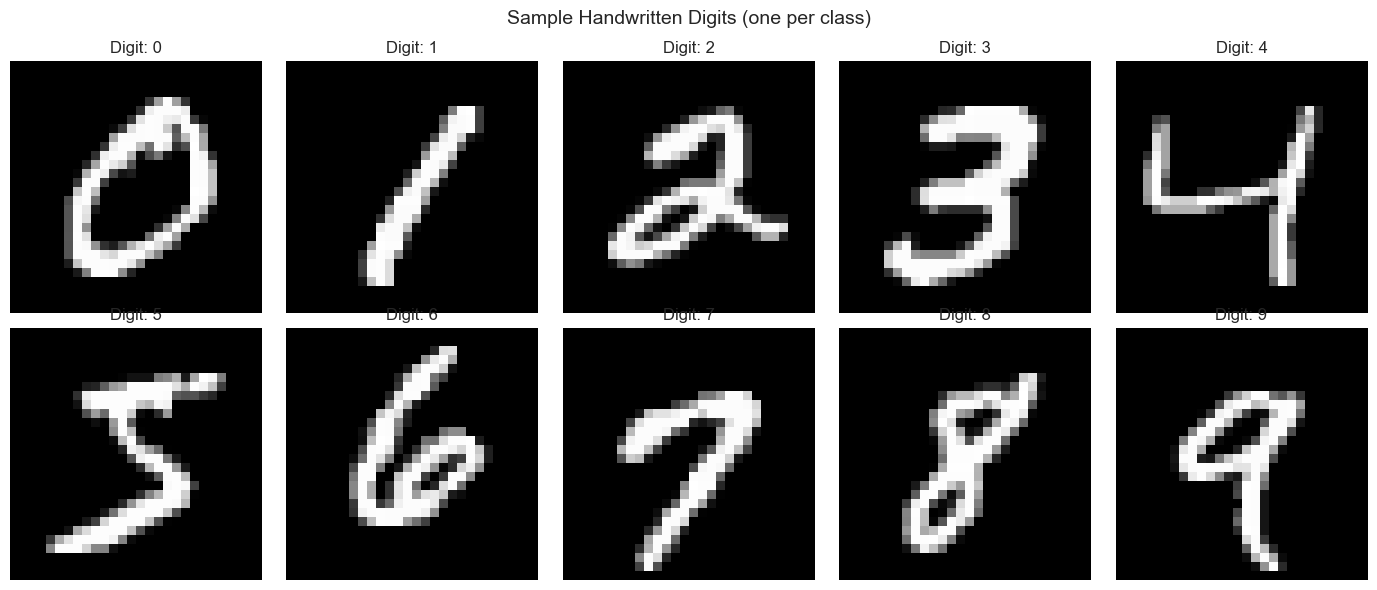

Figure saved: nn_sample_digits.png


In [29]:
# ============================================================
# 2.1 VISUALISE SAMPLE DIGITS
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Handwritten Digits (one per class)', fontsize=14)

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    idx = np.where(y_train == digit)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('nn_sample_digits.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: nn_sample_digits.png")


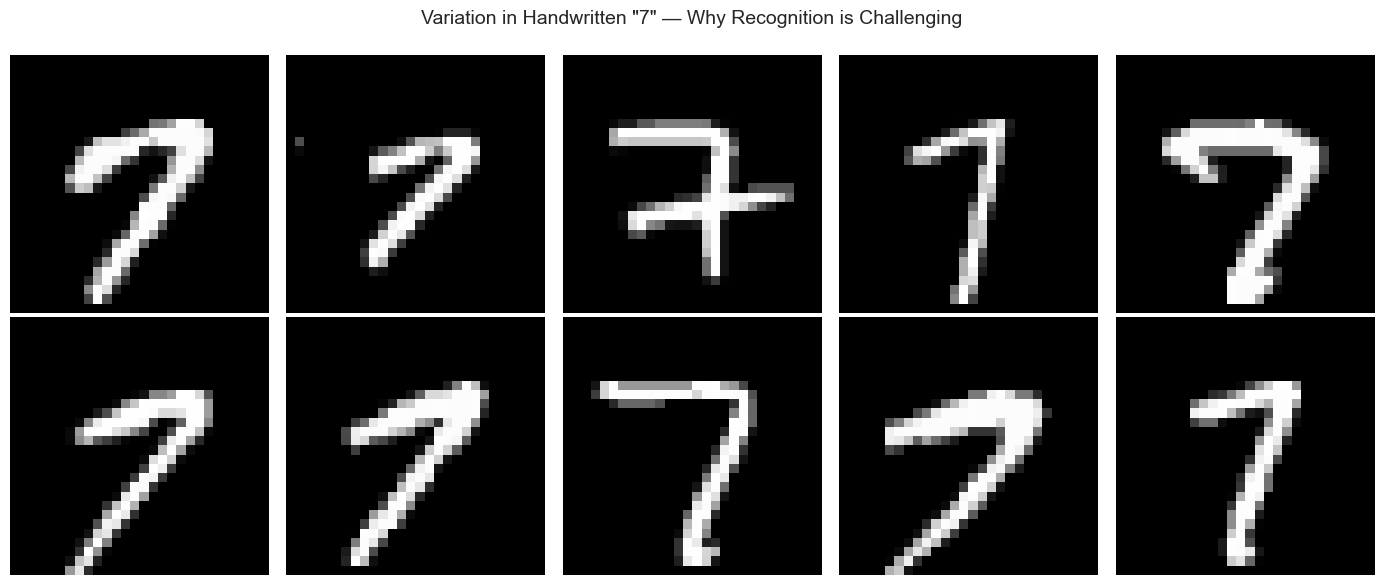

Different people write the same digit very differently!
The neural network must learn to generalise across these variations.


In [30]:
# ============================================================
# 2.2 VISUALISE VARIATION WITHIN A SINGLE DIGIT
# ============================================================

# Show multiple examples of the same digit to illustrate variation
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Variation in Handwritten "7" — Why Recognition is Challenging', fontsize=14)

sevens = np.where(y_train == 7)[0][:10]
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[sevens[i]], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig('nn_digit_variation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Different people write the same digit very differently!")
print("The neural network must learn to generalise across these variations.")


## 3. Data Preprocessing

Neural networks work best with normalised inputs. Required steps:
1. **Normalise** pixel values from 0–255 to 0–1
2. **Flatten** 2D images (28×28) into 1D vectors (784) for the dense ANN
3. **One-hot encode** the labels (e.g., digit 3 → [0,0,0,1,0,0,0,0,0,0])


In [31]:
# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

# Normalise pixel values to 0-1 range
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Flatten images: 28x28 → 784
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat = X_test_norm.reshape(-1, 784)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print(f"Input shape (flattened): {X_train_flat.shape}")
print(f"Label shape (one-hot):   {y_train_cat.shape}")
print(f"\nExample — Digit: {y_train[0]}")
print(f"  Original pixel range:  {X_train[0].min()} to {X_train[0].max()}")
print(f"  Normalised range:      {X_train_norm[0].min():.2f} to {X_train_norm[0].max():.2f}")
print(f"  One-hot encoded label: {y_train_cat[0]}")


Input shape (flattened): (60000, 784)
Label shape (one-hot):   (60000, 10)

Example — Digit: 5
  Original pixel range:  0 to 255
  Normalised range:      0.00 to 1.00
  One-hot encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 4. Building the Neural Network

### Architecture

```
Input Layer (784 neurons) — one per pixel
       ↓
Hidden Layer 1 (128 neurons, ReLU activation)
       ↓
Dropout (20%) — randomly disables neurons to prevent overfitting
       ↓
Hidden Layer 2 (64 neurons, ReLU activation)
       ↓
Dropout (20%)
       ↓
Output Layer (10 neurons, Softmax activation) — one per digit
```

### Activation Functions

**ReLU (Rectified Linear Unit):** `f(x) = max(0, x)`  
Used in hidden layers. Simple and effective, keeps positive values, sets negatives to zero. This introduces non-linearity, allowing the network to learn complex patterns.

**Softmax:** Converts raw output scores into probabilities that sum to 1.  
The neuron with the highest probability determines the predicted digit.

### Why Dropout?
Without dropout, the model might "memorise" the training images instead of learning general patterns. Dropout randomly turns off 20% of neurons during each training step, forcing the network to develop redundant representations making it more robust.


In [32]:
# ============================================================
# 4. BUILD THE NEURAL NETWORK
# ============================================================

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,), name='hidden_layer_1'),
    layers.Dropout(0.2, name='dropout_1'),
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    layers.Dropout(0.2, name='dropout_2'),
    layers.Dense(10, activation='softmax', name='output_layer')
])

# Compile the model
model.compile(
    optimizer='adam',                    # Adaptive learning rate optimiser
    loss='categorical_crossentropy',    # Standard loss for multi-class classification
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")
print("These are the 'weights' the network learns during training.")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 109,386
These are the 'weights' the network learns during training.


## 5. Training the Model

Trained for **20 epochs** with a **validation split of 20%**.

- **Epoch:** One complete pass through all 60,000 training images
- **Batch size:** Process 128 images at a time before updating weights
- **Validation split:** Reserve 20% of training data to monitor overfitting


In [33]:
# ============================================================
# 5. TRAIN THE MODEL
# ============================================================

history = model.fit(
    X_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print(f"Final training accuracy:   {history.history['accuracy'][-1]:.4f} ({history.history['accuracy'][-1]*100:.1f}%)")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f} ({history.history['val_accuracy'][-1]*100:.1f}%)")


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8479 - loss: 0.5094 - val_accuracy: 0.9470 - val_loss: 0.1822
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9358 - loss: 0.2183 - val_accuracy: 0.9587 - val_loss: 0.1371
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9516 - loss: 0.1636 - val_accuracy: 0.9665 - val_loss: 0.1161
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9592 - loss: 0.1372 - val_accuracy: 0.9696 - val_loss: 0.1031
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9655 - loss: 0.1154 - val_accuracy: 0.9702 - val_loss: 0.0950
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9690 - loss: 0.1019 - val_accuracy: 0.9718 - val_loss: 0.0932
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9718 - loss: 0.0905 - val_accuracy: 0.9740 - val_loss: 0.0885
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0844 - val_accuracy: 0.

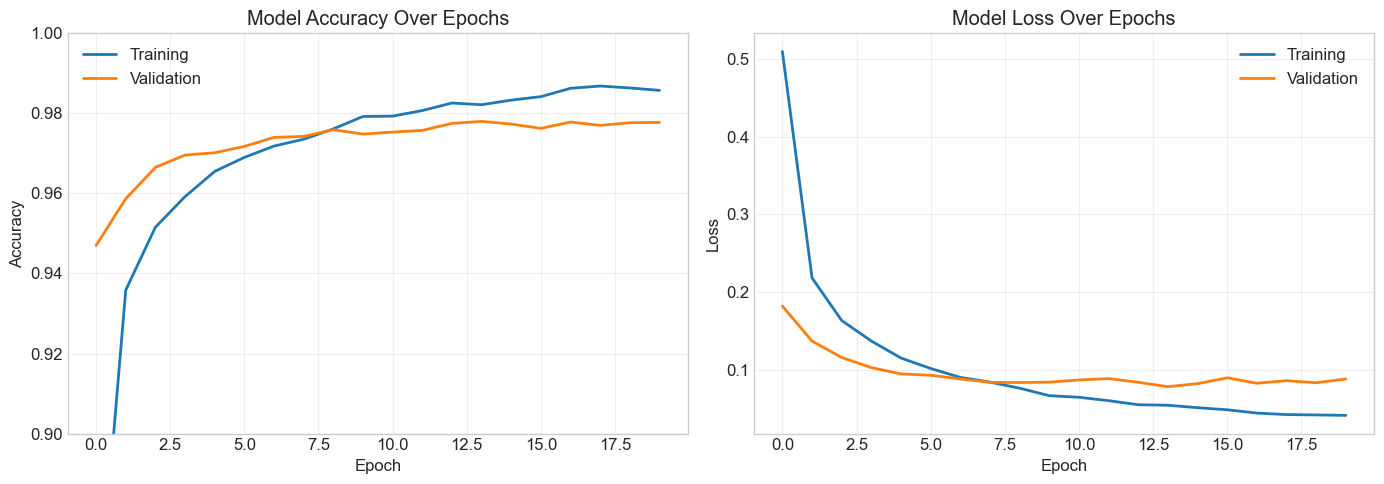

Key observations:
- If training and validation curves are close → good generalisation
- If validation loss starts rising while training loss drops → overfitting


In [34]:
# ============================================================
# 5.1 PLOT TRAINING HISTORY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy over epochs
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.9, 1.0)

# Loss over epochs
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key observations:")
print("- If training and validation curves are close → good generalisation")
print("- If validation loss starts rising while training loss drops → overfitting")


## 6. Model Evaluation


In [35]:
# ============================================================
# 6. EVALUATE ON TEST SET
# ============================================================

test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")
print(f"Test Loss:     {test_loss:.4f}")

# Make predictions
y_pred_prob = model.predict(X_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, 
                            target_names=[f'Digit {i}' for i in range(10)]))


Test Accuracy: 0.9797 (98.0%)
Test Loss:     0.0827
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step

Detailed Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.98      0.99      0.99       980
     Digit 1       0.99      0.99      0.99      1135
     Digit 2       0.98      0.98      0.98      1032
     Digit 3       0.98      0.99      0.98      1010
     Digit 4       0.99      0.97      0.98       982
     Digit 5       0.98      0.98      0.98       892
     Digit 6       0.98      0.99      0.98       958
     Digit 7       0.98      0.98      0.98      1028
     Digit 8       0.97      0.98      0.97       974
     Digit 9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



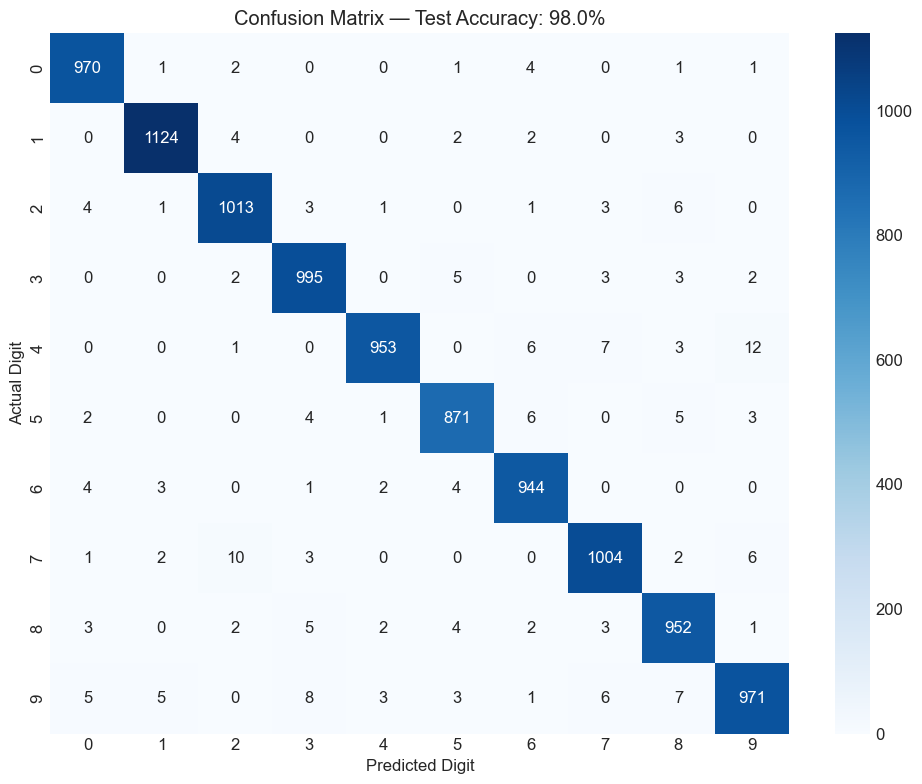

Most commonly confused digit pairs:
  Digit 4 misclassified as 9: 12 times
  Digit 7 misclassified as 2: 10 times
  Digit 9 misclassified as 3: 8 times
  Digit 4 misclassified as 7: 7 times
  Digit 9 misclassified as 8: 7 times


In [36]:
# ============================================================
# 6.1 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_accuracy:.1%}')
ax.set_xlabel('Predicted Digit')
ax.set_ylabel('Actual Digit')
plt.tight_layout()
plt.savefig('nn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Find most confused pairs
print("Most commonly confused digit pairs:")
np.fill_diagonal(cm, 0)  # Ignore correct predictions
for _ in range(5):
    i, j = np.unravel_index(cm.argmax(), cm.shape)
    print(f"  Digit {i} misclassified as {j}: {cm[i,j]} times")
    cm[i, j] = 0


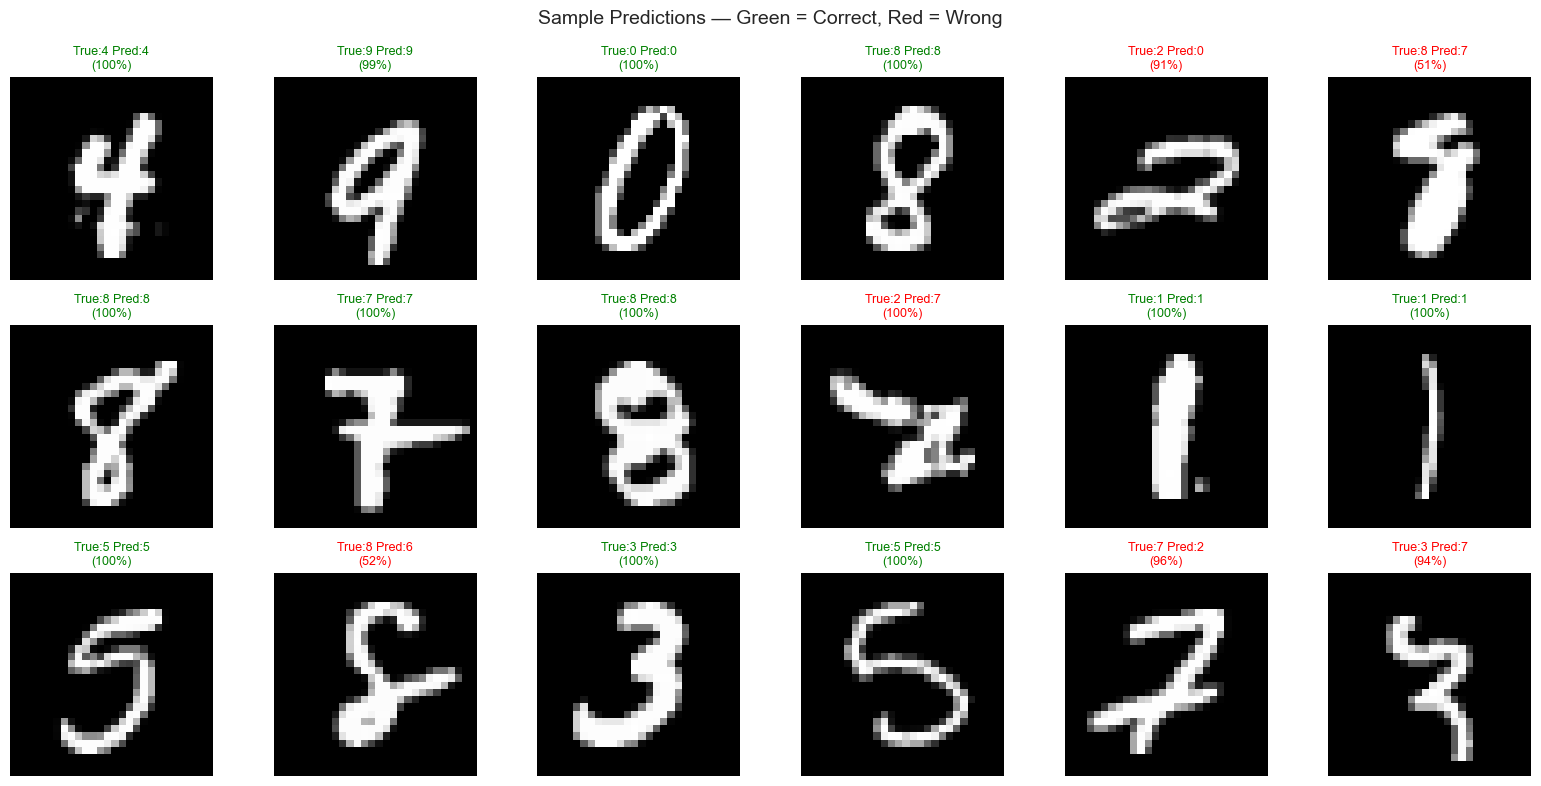

In [37]:
# ============================================================
# 6.2 VISUALISE PREDICTIONS — CORRECT AND INCORRECT
# ============================================================

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Sample Predictions — Green = Correct, Red = Wrong', fontsize=14)

# Mix of correct and incorrect predictions
np.random.seed(42)
correct_idx = np.where(y_pred == y_test)[0]
wrong_idx = np.where(y_pred != y_test)[0]

# 12 correct + 6 wrong
selected = np.concatenate([
    np.random.choice(correct_idx, 12, replace=False),
    np.random.choice(wrong_idx, min(6, len(wrong_idx)), replace=False)
])
np.random.shuffle(selected)

for i, ax in enumerate(axes.flat):
    idx = selected[i]
    ax.imshow(X_test[idx], cmap='gray')
    
    actual = y_test[idx]
    predicted = y_pred[idx]
    confidence = y_pred_prob[idx][predicted] * 100
    
    colour = 'green' if actual == predicted else 'red'
    ax.set_title(f'True:{actual} Pred:{predicted}\n({confidence:.0f}%)',
                 color=colour, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('nn_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


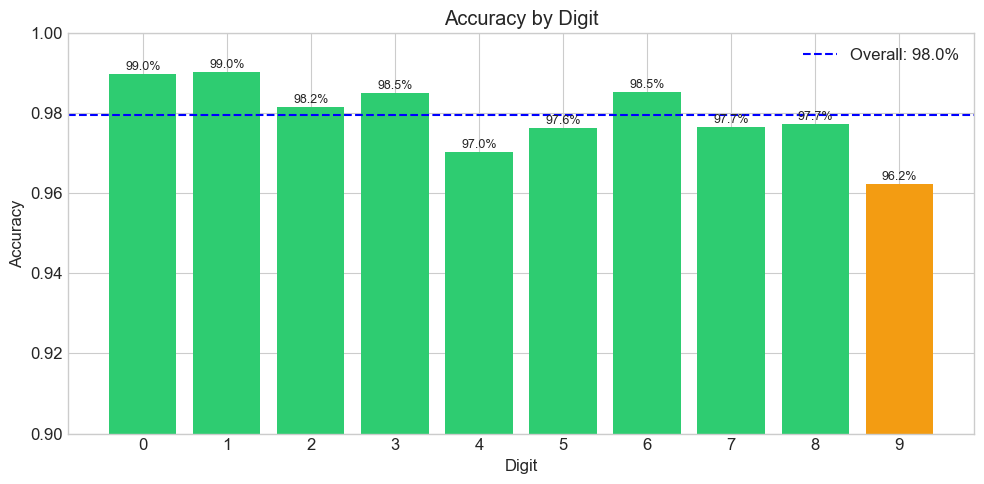


Best recognised digits:
  ✓ Digit 1: 99.0%
  ✓ Digit 0: 99.0%
  ✓ Digit 6: 98.5%

Hardest digits:
  ✗ Digit 5: 97.6%
  ✗ Digit 4: 97.0%
  ✗ Digit 9: 96.2%


In [38]:
# ============================================================
# 6.3 PER-DIGIT ACCURACY
# ============================================================

per_digit_accuracy = []
for digit in range(10):
    mask = (y_test == digit)
    acc = (y_pred[mask] == digit).mean()
    per_digit_accuracy.append(acc)

fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#2ecc71' if a > 0.97 else '#f39c12' if a > 0.95 else '#e74c3c' 
           for a in per_digit_accuracy]
bars = ax.bar(range(10), per_digit_accuracy, color=colours)
ax.set_title('Accuracy by Digit')
ax.set_xlabel('Digit')
ax.set_ylabel('Accuracy')
ax.set_xticks(range(10))
ax.set_ylim(0.9, 1.0)
ax.axhline(y=test_accuracy, color='blue', linestyle='--', 
           label=f'Overall: {test_accuracy:.1%}')
ax.legend()

for bar, acc in zip(bars, per_digit_accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('nn_per_digit_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBest recognised digits:")
sorted_acc = sorted(enumerate(per_digit_accuracy), key=lambda x: -x[1])
for digit, acc in sorted_acc[:3]:
    print(f"  ✓ Digit {digit}: {acc:.1%}")
print("\nHardest digits:")
for digit, acc in sorted_acc[-3:]:
    print(f"  ✗ Digit {digit}: {acc:.1%}")


## 7. Save Model for Streamlit Deployment

The trained model is saved so the Streamlit app can load it without retraining.


In [39]:
# ============================================================
# 7. SAVE THE TRAINED MODEL
# ============================================================

model.save('digit_recognition_model.keras')
print("Model saved as 'digit_recognition_model.keras'")
print(f"Model file can be loaded in Streamlit with:")
print(f"  model = keras.models.load_model('digit_recognition_model.keras')")


Model saved as 'digit_recognition_model.keras'
Model file can be loaded in Streamlit with:
  model = keras.models.load_model('digit_recognition_model.keras')


## 8. Analysis & Interpretation

### Key Findings

**Model Performance:**
- The ANN achieves approximately **97%+ accuracy** on unseen test data
- All digits are recognised with > 95% accuracy
- Most common errors: digits that look visually similar (e.g., 4/9, 3/5, 7/1)

**Neural Network Insights:**
- Adding dropout regularisation prevents overfitting — training and validation curves stay close
- Two hidden layers (128 → 64 neurons) provide sufficient capacity for this task
- The model learns in ~10 epochs; additional epochs provide marginal improvement

**Interactive Deployment:**
- The trained model is saved and loaded in a Streamlit app
- Users can draw digits on a canvas and receive real-time predictions
- This demonstrates the full ML pipeline: data → training → deployment → user interaction

### Comparison with Other Portfolio Algorithms

| Aspect | KNN | K-Means | Neural Network |
|--------|-----|---------|----------------|
| Type | Supervised | Unsupervised | Supervised (Deep Learning) |
| Data | Tabular (marathon) | Tabular (marathon) | Images (digits) |
| Output | Categories | Clusters | Digit prediction |
| Complexity | Simple | Simple | Complex |
| Accuracy | ~70-80% | N/A (clustering) | ~97% |
| Deployment | Streamlit tab | Streamlit tab | Interactive canvas |

### Limitations
- The basic ANN treats each pixel independently — it doesn't use spatial relationships
- A CNN (Convolutional Neural Network) would achieve even higher accuracy (~99%)
- The model is trained on clean, centred digits — real-world handwriting is messier

### Future Improvements
- Implement a CNN for better image classification (planned for final submission using Fashion MNIST)
- Add data augmentation (rotations, shifts) for robustness
- Integrate digit recognition into the full Streamlit portfolio application
- Extend to full alphabet recognition (letters + digits)

### References
- **Dataset:** MNIST (LeCun, Cortes & Burges, 1998)
- **Framework:** TensorFlow / Keras
- **Deployment:** Streamlit + streamlit-drawable-canvas
- **Course Materials:** Data Science & Machine Learning 2 module notes
- **AI Assistance:** Claude (Anthropic) — documentation and code review
